# Colocalisation analysis over time
Tracks kymographs, then performs pairwise linking of tracks from two different channels based on their initial positions.  Displacement of each track is calculated relative to its starting position and tracks are visualised as displacement pairs on a 2D plot.

In [5]:
# Importing libraries
from kymotools.detect import Detector
from kymotools.kymo import PeakMeasures
from kymotools.interactive import retain_tracks_by_id
from n2v.models import N2V
from scipy.optimize import curve_fit

import csv
import kymotools.io as kio
import matplotlib.pyplot as plt
import numpy as np
import os

In [6]:
# Parameters
input_path = './examples/input/' # Path to folder containing images to process
output_path = './examples/output/' # Path to folder in which to save ouput
model_path = '../n2v-models/' # Set to None if not using N2V
model_name = '2024-02-02_Cropped_Keras' # Set to None if not using N2V
channel_1 = 0 # First channel to track
channel_2 = 1 # Second channel to track
max_separation = 2 # Maximum separation between detections for them to be linked (pixel units)

In [7]:
# We're comparing against a perfect correlation with gradient of 1 and a zero intercept
def straightlineGrad1(x,c):
    return x+c

def detect_and_track(input_path, output_path, name, model):
    # Determining paths required later
    rootname = os.path.splitext(name)[0]
    
    # Loading images
    image_1 = kio.read_image(input_path+name,channel_1,x_range=None)
    image_2 = kio.read_image(input_path+name,channel_2,x_range=None)
    
    # Initialising Detector
    detector = Detector(half_t_w=1, peak_det_thresh=1, n_max=6, a_lb = 0.5, c_lb=2, c_ub=8, c_def=6, max_dist=18, min_track_length = 9,
                    track_heritage_weight=100, starting_window=10)
    # If a model was provided, 
    if model is not None:
        pred_image = model.predict(image_1, axes='YX', n_tiles=(2,1))
        image_1 = pred_image - np.min(pred_image[:])
        pred_image = model.predict(image_2, axes='YX', n_tiles=(2,1))
        image_2 = pred_image - np.min(pred_image[:])
    
    # Detect peaks and track
    tracks_1 = detector.detect(image_1)
    tracks_2 = detector.detect(image_2)

    # Removing tracks
    display(kio.create_track_overlay(tracks_1,image_1))
    kio.save_overlay(tracks_1,image_1,output_path+rootname+'_C'+str(channel_1)+"_initial_overlay")
    retain_tracks_by_id(tracks_1)
    display(kio.create_track_overlay(tracks_2,image_2))
    kio.save_overlay(tracks_2,image_2,output_path+rootname+'_C'+str(channel_2)+"_initial_overlay")
    retain_tracks_by_id(tracks_2)
    
    # Saving overlays
    kio.save_overlay(tracks_1,image_1,output_path+rootname+"_overlay_1")
    kio.save_overlay(tracks_2,image_2,output_path+rootname+"_overlay_2")

    return tracks_1, tracks_2

def analyse_nns(output_path, name, tracks_1, tracks_2):
    # Getting first instance of each track
    peaks_1 = {}
    for track_1 in tracks_1.values():
        peaks_1[track_1.ID] = track_1.peaks[0]
    
    peaks_2 = {}
    for track_2 in tracks_2.values():
        peaks_2[track_2.ID] = track_2.peaks[0]
    
    # Nearest neighbour measurement for first timepoints
    for peak_1 in peaks_1.values():
        peak_1.calculate_nearest_neighbour(peaks_2)
    
    for peak_2 in peaks_2.values():
        peak_2.calculate_nearest_neighbour(peaks_1)
    
    # Calculating distance between linked tracks for each timepoint
    dists = []
    for track_1 in tracks_1.values():
        track_2_ID = track_1.peaks[0].measures[PeakMeasures.NN_ID]
        track_2 = tracks_2[track_2_ID]
    
        x0_1 = track_1.peaks[0].b
        x0_2 = track_2.peaks[0].b

        if abs(x0_1-x0_2) > max_separation:
            continue

        # Calculating the R2 for this set relative to a straightline with gradient 1, but 
        # fittable y-axis offset.  This can account for the initial separation between points 
        # being a bit off
        curr_dists = []
        timepoints = max(max(track_1.get_timepoints()),max(track_2.get_timepoints()))
        for t in range(timepoints):
            if t in track_1.peaks and t in track_2.peaks:
                peak_1 = track_1.peaks[t]
                peak_2 = track_2.peaks[t]
                curr_dists.append([peak_1.b - x0_1, peak_2.b - x0_2])
        curr_dists = np.array(curr_dists)

        popt, pcov = curve_fit(straightlineGrad1,curr_dists[:,0],curr_dists[:,1])
        residuals = curr_dists[:,1] - straightlineGrad1(curr_dists[:,0], *popt)
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((curr_dists[:,1]-np.mean(curr_dists[:,1]))**2)
        r2 = 1 - (ss_res / ss_tot)

        timepoints = max(max(track_1.get_timepoints()),max(track_2.get_timepoints()))
        for t in range(timepoints):
            if t in track_1.peaks and t in track_2.peaks:
                peak_1 = track_1.peaks[t]
                peak_2 = track_2.peaks[t]
                dists.append([t, track_1.ID, track_2.ID, peak_1.ID, peak_2.ID, peak_1.b, peak_2.b, peak_1.b - x0_1, peak_2.b - x0_2, abs(x0_1-x0_2),r2,popt[0]])
    
    # Saving results
    rootname = os.path.splitext(name)[0]
    with open(output_path+rootname+"_displacements.csv", 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Timepoint','Track1 ID','Track2 ID','Peak1 ID','Peak2 ID','Peak1 pos (px)','Peak2 pos (px)','Displacement1 (px)','Displacement2 (px)','Initial separation (px)','R2','Intercept'])
        writer.writerows(dists)
    
    return dists

def plot_results(output_path, name, dists):    
    # Determining paths required later
    rootname = os.path.splitext(name)[0]
    
    # Create displacement plot and save
    dists = np.array(dists)
    ax_min = min(min(dists[:,7]),min(dists[:,8]))
    ax_max = max(max(dists[:,7]),max(dists[:,8]))
    
    plt.plot([ax_min,ax_max],[ax_min,ax_max],'grey', linewidth=1)
    plt.scatter(dists[:,7], dists[:,8], c=dists[:,1], cmap='Set1', s=10, marker='.')
    plt.gca().set_aspect(1)
    plt.xlabel('Displacement 1 (px)')
    plt.ylabel('Displacement 2 (px)')
    plt.savefig(output_path+rootname+"_displacement_(colour_IDs)_plot.png")
    plt.savefig(output_path+rootname+"_displacement_(colour_IDs)_plot.svg")
    plt.show()
    
    # Create displacement plot and save
    dists = np.array(dists)
    plt.plot([ax_min,ax_max],[ax_min,ax_max],'grey', linewidth=1)
    plt.scatter(dists[:,7], dists[:,8], c=dists[:,9], cmap='plasma', s=10, marker='.')
    plt.gca().set_aspect(1)
    plt.xlabel('Displacement 1 (px)')
    plt.ylabel('Displacement 2 (px)')
    plt.savefig(output_path+rootname+"_displacement_(colour_sep)_plot.png")
    plt.savefig(output_path+rootname+"_displacement_(colour_sep)_plot.svg")
    plt.show()
    

Loading network weights from '2024-02-02_Cropped_Keras.h5'.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step


 50%|█████     | 1/2 [00:00<00:00, 127100.12it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


100%|██████████| 2/2 [00:00<00:00,  8.79it/s]    


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


 50%|█████     | 1/2 [00:00<00:00, 55188.21it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


100%|██████████| 1270/1270 [00:07<00:00, 178.30it/s]


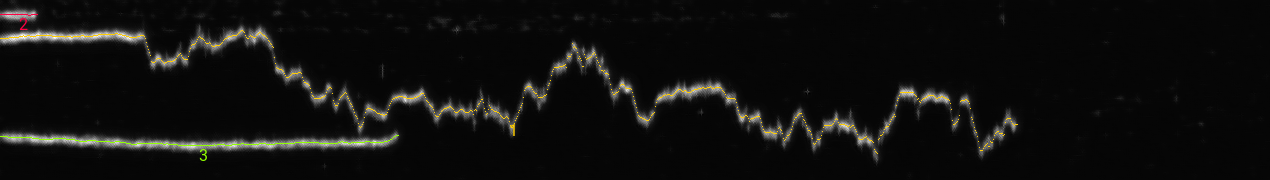

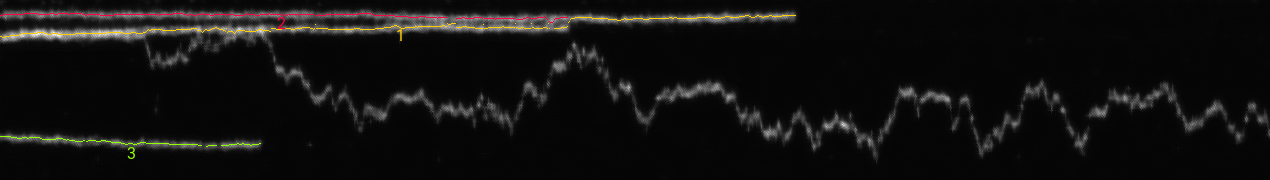

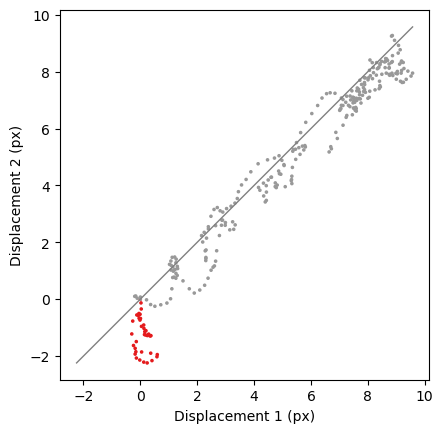

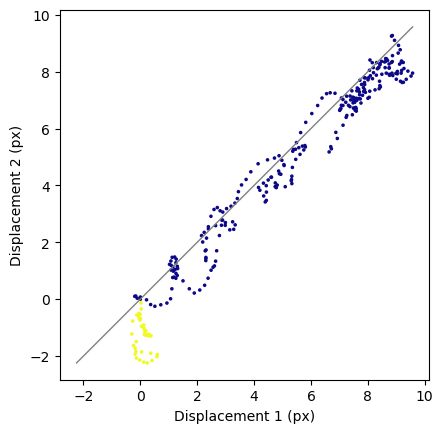

In [8]:
# Loading N2V model
if model_path is not None:
    model = N2V(config=None, name=model_name, basedir=model_path)
else:
    model = None

# Looping over all files in folder, processing any tifs
for name in os.listdir(input_path):
    if os.path.splitext(name)[1] == ".tif":
        tracks_1, tracks_2 = detect_and_track(input_path, output_path, name, model)
            
        dists = analyse_nns(output_path, name, tracks_1, tracks_2)
        plot_results(output_path, name, dists)
